# Personality Prediction using NLP: Per-Axis Binary Classification

Predicts MBTI personality type from social media posts by treating each of the 4 axes as an independent binary classification problem.

| Axis | Labels |
|------|--------|
| Mind | Introversion (I) vs Extroversion (E) |
| Information | Intuition (N) vs Sensing (S) |
| Decision | Thinking (T) vs Feeling (F) |
| Lifestyle | Judging (J) vs Perceiving (P) |

**Dataset:** [MBTI Personality Type Dataset](https://www.kaggle.com/datasets/datasnaek/mbti-type) on Kaggle  
Download and place `mbti_1.csv` in the same directory as this notebook.

**Approach:** TF-IDF features + Logistic Regression per axis, with full evaluation (F1, ROC-AUC, confusion matrix)

## 1. Setup and Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

AXES = [
    ('IE', 'I', 'E', 'Mind'),
    ('NS', 'N', 'S', 'Information'),
    ('TF', 'T', 'F', 'Decision'),
    ('JP', 'J', 'P', 'Lifestyle'),
]

## 2. Dataset Loading

In [4]:
import os

# works in VSCode notebooks; falls back to cwd for other environments
_nb_file = globals().get('__vsc_ipynb_file__') or globals().get('__file__')
if _nb_file:
    os.chdir(os.path.dirname(os.path.abspath(_nb_file)))

df = pd.read_csv('mbti_1.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (8675, 2)


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [5]:
# Create a binary label column for each axis
df['IE'] = df['type'].apply(lambda x: 0 if x[0] == 'I' else 1)  # 0=I, 1=E
df['NS'] = df['type'].apply(lambda x: 0 if x[1] == 'N' else 1)  # 0=N, 1=S
df['TF'] = df['type'].apply(lambda x: 0 if x[2] == 'T' else 1)  # 0=T, 1=F
df['JP'] = df['type'].apply(lambda x: 0 if x[3] == 'J' else 1)  # 0=J, 1=P

df[['type', 'IE', 'NS', 'TF', 'JP']].head(10)

,type,IE,NS,TF,JP
0,INFJ,0,0,1,0
1,ENTP,1,0,0,1
2,INTP,0,0,0,1
3,INTJ,0,0,0,0
4,ENTJ,1,0,0,0
5,INTJ,0,0,0,0
6,INFJ,0,0,1,0
7,INTJ,0,0,0,0
8,INFJ,0,0,1,0
9,INTP,0,0,0,1


## 3. Exploratory Data Analysis

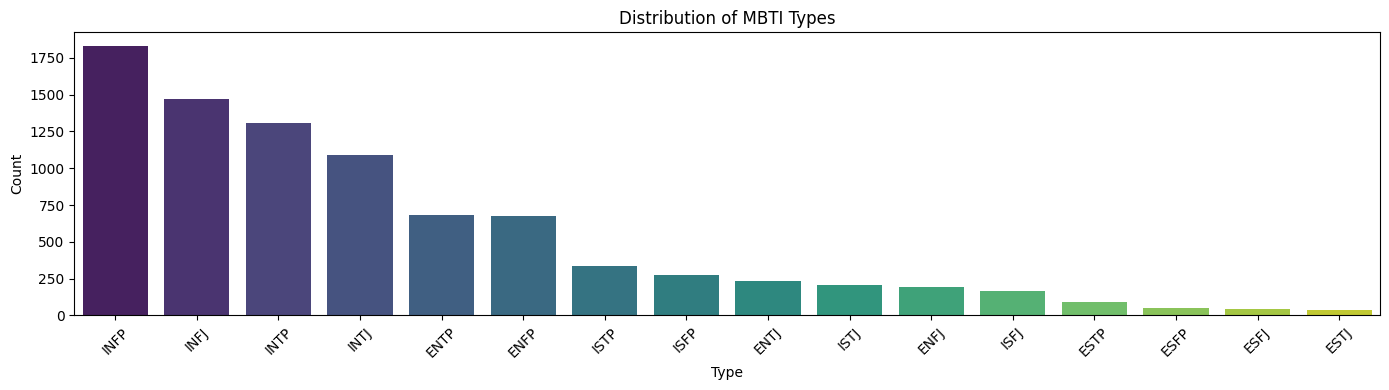

In [6]:
# Distribution of all 16 MBTI types
plt.figure(figsize=(14, 4))
order = df['type'].value_counts().index
sns.countplot(data=df, x='type', order=order, palette='viridis')
plt.title('Distribution of MBTI Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

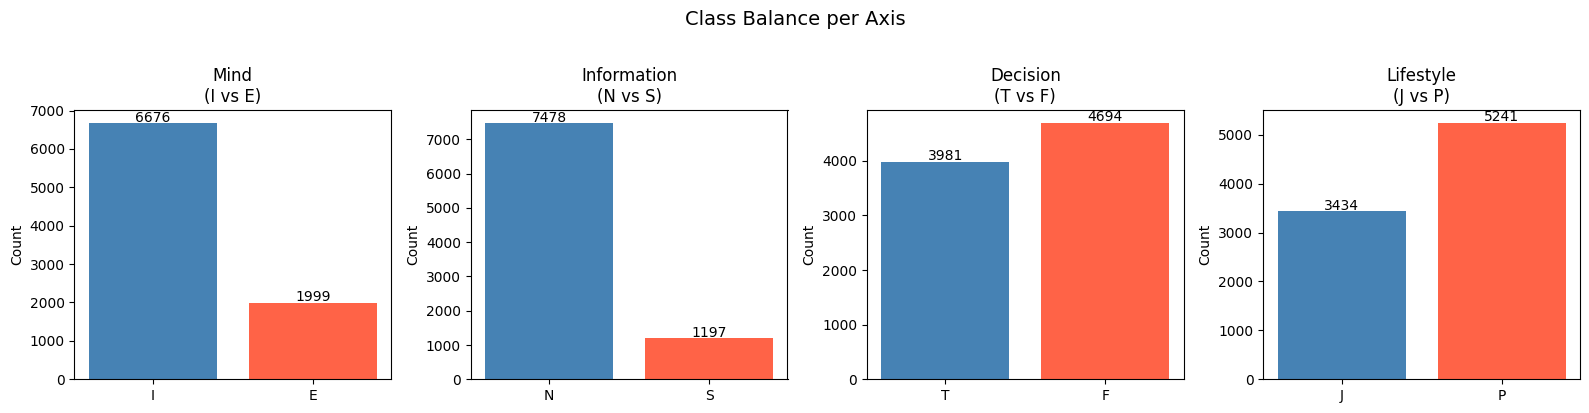

In [7]:
# Per-axis class balance
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (col, label0, label1, title) in zip(axes, AXES):
    counts = df[col].value_counts().sort_index()
    ax.bar([label0, label1], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(f'{title}\n({label0} vs {label1})')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, str(v), ha='center', fontsize=10)

plt.suptitle('Class Balance per Axis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

In [8]:
def clean_posts(text):
    text = text.lower()
    text = re.sub(r'https?://\S+', '', text)          # remove URLs
    text = re.sub(r'\|+', ' ', text)                   # replace post separators
    text = re.sub(r'[^a-z\s]', '', text)               # keep only letters
    # remove MBTI type mentions to prevent data leakage
    mbti_types = ['infj','infp','intj','intp','isfj','isfp','istj','istp',
                  'enfj','enfp','entj','entp','esfj','esfp','estj','estp']
    for t in mbti_types:
        text = text.replace(t, '')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_posts'] = df['posts'].apply(clean_posts)
print('Sample cleaned post:')
print(df['clean_posts'].iloc[0][:300])

Sample cleaned post:
and moments sportscenter not top ten plays pranks what has been the most lifechanging experience in your life on repeat for most of today may the perc experience immerse you the last thing my friend posted on his facebook before committing suicide the next day rest in peace sorry to hear of your dis


## 5. TF-IDF Feature Extraction

In [9]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=3
)

X = tfidf.fit_transform(df['clean_posts'])
print(f'TF-IDF matrix shape: {X.shape}')

TF-IDF matrix shape: (8675, 10000)


## 6. Binary Classification: One Model per Axis

In [10]:
results = {}
models = {}

for col, label0, label1, axis_name in AXES:
    y = df[col].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    models[col] = (model, X_test, y_test)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[col] = {
        'axis': axis_name,
        'labels': f'{label0} vs {label1}',
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='weighted'),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'roc_auc': roc_auc_score(y_test, y_prob),
    }

    print(f'\n--- {axis_name} ({label0} vs {label1}) ---')
    print(classification_report(y_test, y_pred, target_names=[label0, label1]))


--- Mind (I vs E) ---
              precision    recall  f1-score   support

           I       0.86      0.79      0.82      1335
           E       0.45      0.58      0.51       400

    accuracy                           0.74      1735
   macro avg       0.66      0.68      0.67      1735
weighted avg       0.77      0.74      0.75      1735


--- Information (N vs S) ---
              precision    recall  f1-score   support

           N       0.92      0.86      0.89      1496
           S       0.37      0.52      0.43       239

    accuracy                           0.81      1735
   macro avg       0.64      0.69      0.66      1735
weighted avg       0.84      0.81      0.82      1735


--- Decision (T vs F) ---
              precision    recall  f1-score   support

           T       0.76      0.78      0.77       796
           F       0.81      0.78      0.80       939

    accuracy                           0.78      1735
   macro avg       0.78      0.78      0.78     

## 7. Results Summary

In [11]:
results_df = pd.DataFrame(results).T
results_df[['accuracy', 'f1', 'precision', 'recall', 'roc_auc']] = \
    results_df[['accuracy', 'f1', 'precision', 'recall', 'roc_auc']].astype(float).round(4)
results_df

,axis,labels,accuracy,f1,precision,recall,roc_auc
IE,Mind,I vs E,0.7401,0.7507,0.7679,0.7401,0.7671
NS,Information,N vs S,0.8115,0.8245,0.8428,0.8115,0.7760
TF,Decision,T vs F,0.7839,0.7841,0.7848,0.7839,0.8658
JP,Lifestyle,J vs P,0.6778,0.6796,0.6825,0.6778,0.7197


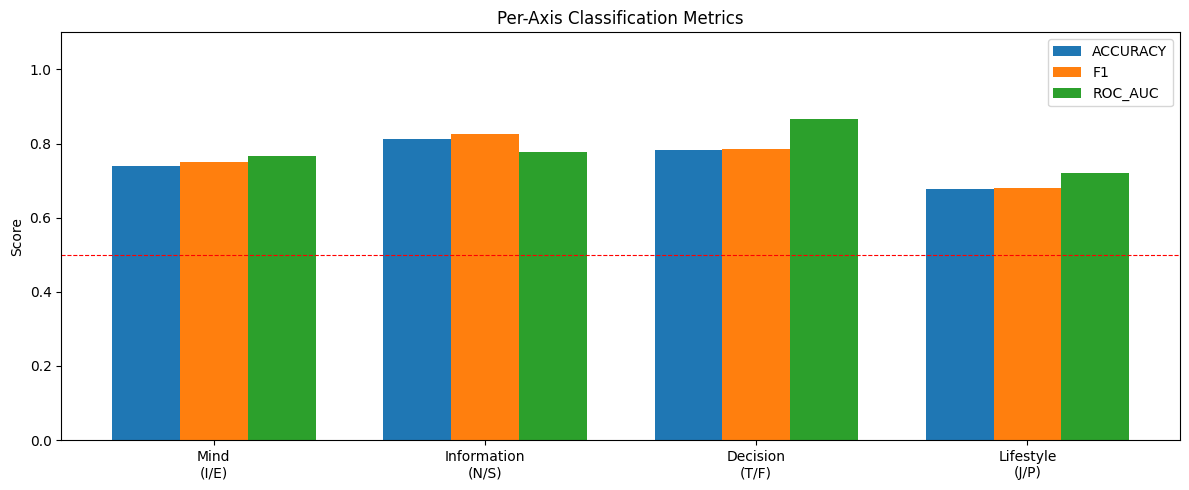

In [12]:
metrics = ['accuracy', 'f1', 'roc_auc']
x = np.arange(len(AXES))
width = 0.25
axis_labels = [f"{name}\n({l0}/{l1})" for _, l0, l1, name in AXES]

fig, ax = plt.subplots(figsize=(12, 5))
for i, metric in enumerate(metrics):
    vals = [results[col][metric] for col, *_ in AXES]
    ax.bar(x + i * width, vals, width, label=metric.upper())

ax.set_xticks(x + width)
ax.set_xticklabels(axis_labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Axis Classification Metrics')
ax.legend()
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='Baseline')
plt.tight_layout()
plt.show()

## 8. Confusion Matrices

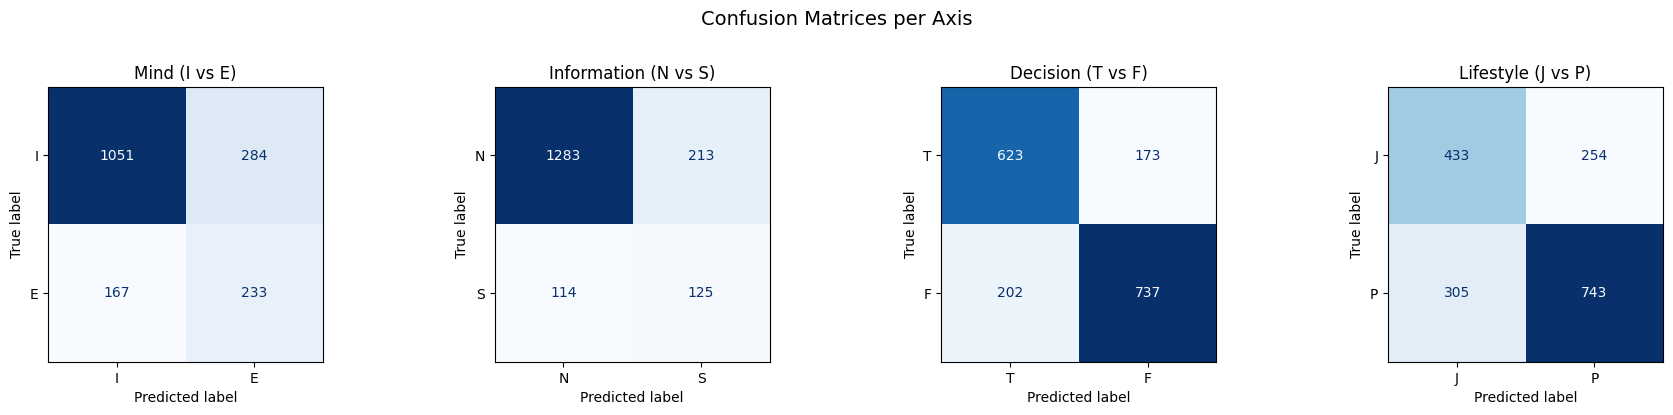

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (col, label0, label1, axis_name) in zip(axes, AXES):
    model, X_test, y_test = models[col]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[label0, label1])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{axis_name} ({label0} vs {label1})')

plt.suptitle('Confusion Matrices per Axis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Top Predictive Words per Axis

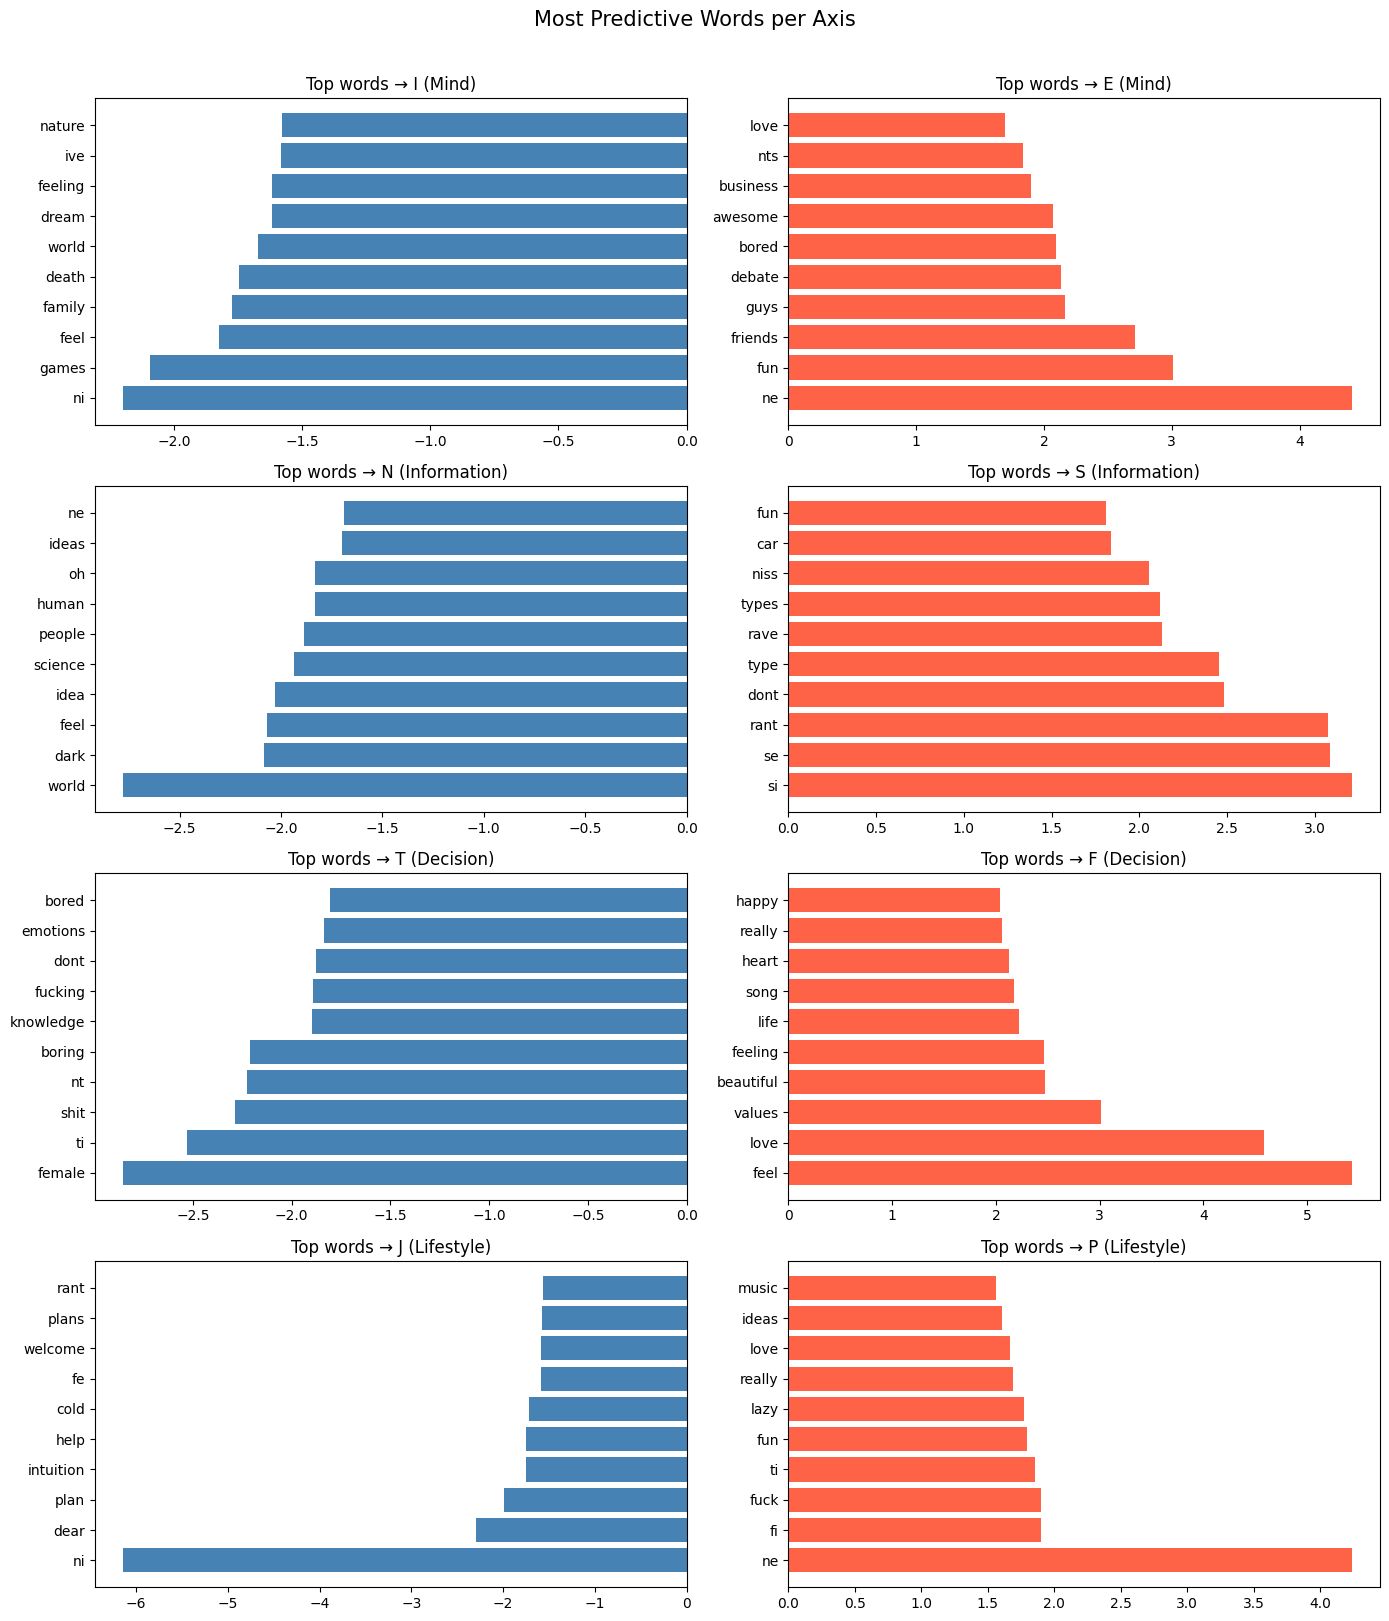

In [14]:
feature_names = np.array(tfidf.get_feature_names_out())
top_n = 10

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for row_idx, (col, label0, label1, axis_name) in enumerate(AXES):
    model, _, _ = models[col]
    coef = model.coef_[0]

    top_label0 = feature_names[np.argsort(coef)[:top_n]]
    top_label1 = feature_names[np.argsort(coef)[-top_n:][::-1]]

    axes[row_idx, 0].barh(top_label0, np.sort(coef)[:top_n], color='steelblue')
    axes[row_idx, 0].set_title(f'Top words → {label0} ({axis_name})')

    axes[row_idx, 1].barh(top_label1, np.sort(coef)[-top_n:][::-1], color='tomato')
    axes[row_idx, 1].set_title(f'Top words → {label1} ({axis_name})')

plt.suptitle('Most Predictive Words per Axis', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 10. Predict on Custom Text

In [15]:
def predict_mbti(text):
    cleaned = clean_posts(text)
    vec = tfidf.transform([cleaned])
    mbti = ''
    print(f'Input: "{text[:80]}..."\n')
    for col, label0, label1, axis_name in AXES:
        model, _, _ = models[col]
        pred = model.predict(vec)[0]
        prob = model.predict_proba(vec)[0]
        letter = label0 if pred == 0 else label1
        confidence = prob[pred]
        mbti += letter
        print(f'{axis_name:12s}: {label0}={prob[0]:.2f}  {label1}={prob[1]:.2f}  → {letter}')
    print(f'\nPredicted MBTI type: {mbti}')
    return mbti

sample = "I love spending time alone with my thoughts and books. I often overthink "\
         "situations and prefer deep meaningful conversations over small talk. "\
         "I rely heavily on logic and analysis when making decisions."

predict_mbti(sample)

Input: "I love spending time alone with my thoughts and books. I often overthink situati..."

Mind        : I=0.78  E=0.22  → I
Information : N=0.68  S=0.32  → N
Decision    : T=0.73  F=0.27  → T
Lifestyle   : J=0.46  P=0.54  → P

Predicted MBTI type: INTP


'INTP'